# Homework 2: Causation, Confounders, and Bad Conclusions. Some Finance too :-) 
## NYC Flights 2013 Analysis

---

### The Business Scenario

You're consulting for **SkyHigh Airlines**, a regional carrier considering expansion from NYC. They need answers to:

1. **Route Expansion**: Which routes should we add?
2. **Competitive Analysis**: Which carriers perform best?
3. **Operations**: Which airport should we operate from?
4. **Scheduling**: When should we schedule flights to minimize delays?
5. **Fleet**: Do aircraft characteristics affect performance?

**The Catch**: Simple averages will lead you astray. This session teaches you to think like a skeptic.

---

### Learning Objectives

**Critical Thinking Skills:**
1. ✅ Identify confounding variables
2. ✅ Recognize selection bias
3. ✅ Understand Simpson's Paradox
4. ✅ Distinguish statistical from practical significance
5. ✅ Know when you CAN'T make causal claims

**Technical Skills:**
1. ✅ Master pd.merge() for joining datasets
2. ✅ Handle multi-column joins
3. ✅ Check join results for unexpected behavior
4. ✅ Create effective comparative visualizations

---

### Dataset Information

**Source**: nycflights13 package (available for Python and R)  
**Period**: All flights departing NYC in 2013 (336,776 flights)  
**Airports**: JFK, LaGuardia (LGA), Newark (EWR)

**Tables**:
- `flights`: Flight details (carrier, time, delays, etc.)
- `weather`: Hourly weather at each airport
- `planes`: Aircraft metadata (year manufactured, type, etc.)
- `airlines`: Carrier names
- `airports`: Airport metadata (location, elevation, etc.)
---

In [ ]:
import pandas as pd
import pandas_datareader.data as web  # To get data from FRED, https://fredaccount.stlouisfed.org/public/datalist/843
from bs4 import BeautifulSoup  # To parse HTML 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# from highlight_text import fig_text
from matplotlib.ticker import FuncFormatter
import requests
import io

from datetime import datetime
import warnings

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

# Set seaborn style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)


# To avoid SSL errors
import urllib.request
opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:,.2f}'.format)

# Data Manipulation: NYC Flights

For this section, we'll use the nycflights13 dataset. In Python, we can access similar data or load CSV versions.

In [ ]:
# Load NYC flights data

flights = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights13/flights.csv")
airlines = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights13/airlines.csv")
airports = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights13/airports.csv")
weather = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights13/weather.csv")

flights.head()




In [5]:
# Understanding the data
print("KEY VARIABLES IN FLIGHTS:")
print("\nDelay columns:")
print("  dep_delay: Departure delay in minutes (negative = early)")
print("  arr_delay: Arrival delay in minutes")
print("\nTime columns:")
print("  year, month, day, hour: When the flight departed")
print("  sched_dep_time: Scheduled departure time (HHMM format)")
print("  dep_time: Actual departure time")
print("\nRoute columns:")
print("  origin: Departure airport (JFK/LGA/EWR)")
print("  dest: Destination airport code")
print("  distance: Flight distance in miles")
print("\nIdentifiers:")
print("  carrier: Airline code (joins to airlines.carrier)")
print("  tailnum: Aircraft ID (joins to planes.tailnum)")

KEY VARIABLES IN FLIGHTS:

Delay columns:
  dep_delay: Departure delay in minutes (negative = early)
  arr_delay: Arrival delay in minutes

Time columns:
  year, month, day, hour: When the flight departed
  sched_dep_time: Scheduled departure time (HHMM format)
  dep_time: Actual departure time

Route columns:
  origin: Departure airport (JFK/LGA/EWR)
  dest: Destination airport code
  distance: Flight distance in miles

Identifiers:
  carrier: Airline code (joins to airlines.carrier)
  tailnum: Aircraft ID (joins to planes.tailnum)


### 🔗 How Tables Connect

```
flights.carrier → airlines.carrier  (Simple join)
flights.tailnum → planes.tailnum   (Simple join)
flights.dest → airports.faa        (Simple join)
flights.{year,month,day,hour,origin} → weather.{year,month,day,hour,origin}  (Multi-column join)
```

---

## Problem 1: Cancelled Flights by Month

What months had the highest and lowest proportion of cancelled flights? Interpret any seasonal patterns. A flight is considerd cancelled if it doesn't have a value for `dep_time`

In [1]:
# Calculate proportion of cancelled flights by month using method chaining
cancelled_by_month = (
    
)

print(cancelled_by_month)

# Visualize with a seaborn barplot
 

()


### 🚨 SELECTION BIAS ALERT!

Notice February:
- **High cancellation rate** (winter weather)
- But **not the highest delays** for flights that flew

**Why?** The flights in WORST conditions got cancelled! They don't appear in delay statistics.

**The lesson**: 
- Our delay analysis only includes flights that flew
- We're systematically MISSING the worst cases
- This underestimates the true impact of weather

**This is survivor bias**: We only observe the "survivors" (flights that completed).

### 💡 Always Ask:
**"What data am I NOT seeing? And is it missing randomly or systematically?"**

## Problem 2: Most Frequent Plane

What plane (specified by the `tailnum` variable) traveled the most times from New York City airports in 2013?

In [2]:
# Find most frequent plane and join with planes data
most_frequent_plane = (
 
)

print("Most frequent plane with >50 seats:")
print(most_frequent_plane)

# Get destinations for this plane
top_tailnum = most_frequent_plane['tailnum'].iloc[0]

destinations = (
    
    )

print(f"\nDestinations for plane {top_tailnum}:")
print(destinations)

Most frequent plane with >50 seats:
()


TypeError: tuple indices must be integers or slices, not str

## Problem 3: Plane Manufacturers

- How many planes have a missing date of manufacture?
- What are the five most common manufacturers?
- Has the distribution of manufacturer changed over time?

Planes with missing manufacture date: 70
Original Grouping Counts:
manufacturer
BOEING                           1630
AIRBUS INDUSTRIE                  400
BOMBARDIER INC                    368
AIRBUS                            336
EMBRAER                           299
MCDONNELL DOUGLAS                 120
MCDONNELL DOUGLAS AIRCRAFT CO     103
MCDONNELL DOUGLAS CORPORATION      14
CANADAIR                            9
CESSNA                              9
PIPER                               5
BEECH                               2
BELL                                2
STEWART MACO                        2
GULFSTREAM AEROSPACE                2
AMERICAN AIRCRAFT INC               2
CANADAIR LTD                        1
BARKER JACK L                       1
DEHAVILLAND                         1
MARZ BARRY                          1
LEBLANC GLENN T                     1
FRIEDEMANN JON                      1
ROBINSON HELICOPTER CO              1
LEARJET INC                         1
LAMBERT 

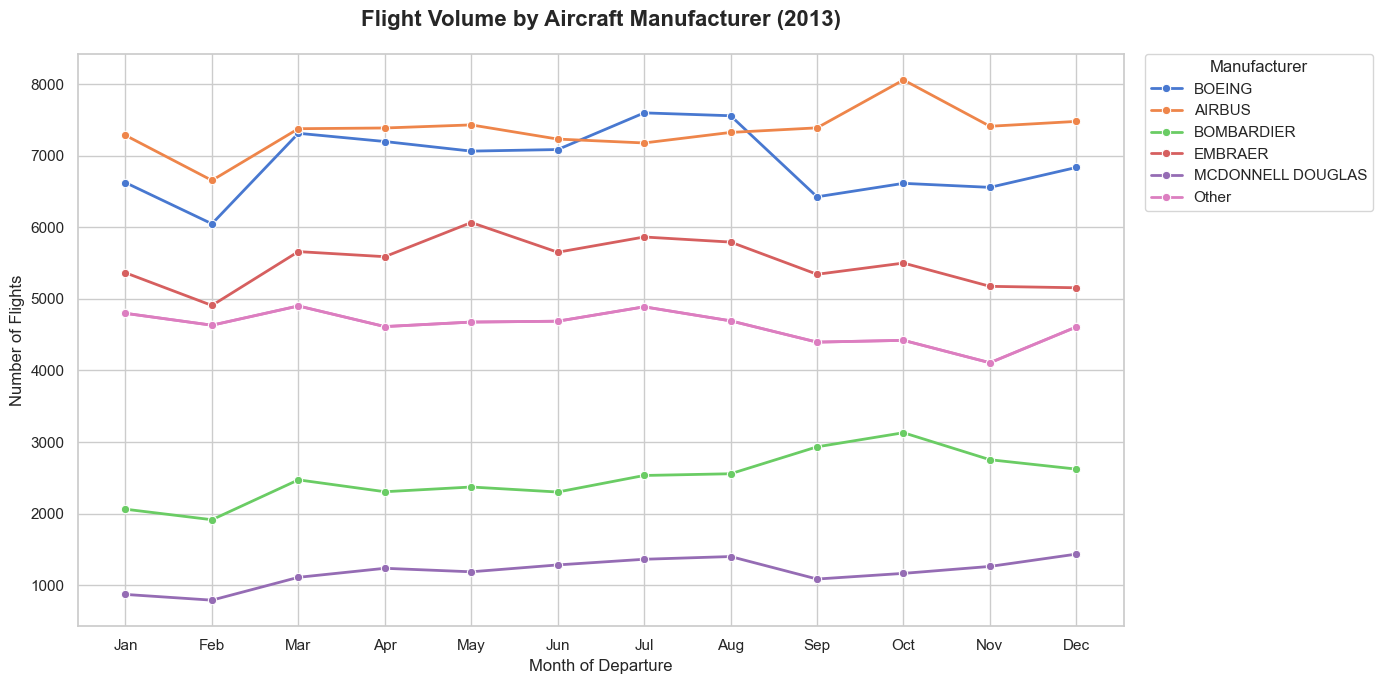

In [ ]:
# --- 1. INITIAL INSPECTION ---
# Count missing values `is.na()`  in the 'year' column of the planes dataset
missing_year = planes['year'].isna().sum()
print(f"Planes with missing manufacture date: {missing_year}")

# --- stanbdardize carier names

# 1. PRE-CLEAN: Remove trailing spaces and standardize case
planes['manufacturer'] = planes['manufacturer'].str.upper().str.strip()

# 2. CASE WHEN: Standardize the big names
conditions = [
    planes['manufacturer'].str.contains('AIRBUS', na=False),
    planes['manufacturer'].str.contains('BOEING', na=False),
    planes['manufacturer'].str.contains('MCDONNELL|DOUGLAS', na=False, regex=True),
    planes['manufacturer'].str.contains('BOMBARDIER|CANADAIR', na=False, regex=True),
    planes['manufacturer'].str.contains('EMBRAER', na=False),
    planes['manufacturer'].str.contains('CESSNA', na=False)
]

choices = [
    'AIRBUS',
    'BOEING',
    'MCDONNELL DOUGLAS',
    'BOMBARDIER',
    'EMBRAER',
    'CESSNA'
]

# Apply the standardization
planes['manufacturer_clean'] = np.select(conditions, choices, default=planes['manufacturer'])

# 3. HANDLE SMALL N: Group infrequent manufacturers into "Other"
n_threshold =   # Define your minimum count here

# Calculate counts for our newly cleaned names
counts = planes['manufacturer_clean'].value_counts()

# Identify names that don't meet the threshold
small_n_manufacturers = counts[counts < n_threshold].index

# Replace those names with 'Other'
planes['manufacturer_final'] = planes['manufacturer_clean'].replace(small_n_manufacturers, 'Other')

# --- Verification ---]
print("Original Grouping Counts:")
print(planes['manufacturer'].value_counts())

print("Final Grouping Counts:")
print(planes['manufacturer_final'].value_counts())


# --- 3. IDENTIFY TOP MANUFACTURERS ---
# We calculate the top 10 to keep the chart from getting too cluttered
top_10_names = (
 
)

print("\nTop 10 Manufacturers (after fuzzy cleaning):")
print(top_10_names)

# --- 4. DATA PREPARATION FOR TIME SERIES ---
# Merge flights with the cleaned plane data
manufacturer_over_time = (
 
)

# --- 5. VISUALIZATION ---
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Create the seabron lineplot, suing sns.lineplot()
lp = sns.lineplot(

)

# Enhance the X-axis labels (convert 1-12 to Jan-Dec)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_labels)

# Styling
plt.title('Flight Volume by Aircraft Manufacturer (2013)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month of Departure', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)

# Move legend outside the plot
plt.legend(title='Manufacturer', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

## Problem 4: Flights to SFO

Which carriers service the route to San Francisco International (SFO)?

  carrier  count                    name percent
3      UA   6819   United Air Lines Inc.   51.2%
4      VX   2197          Virgin America   16.5%
2      DL   1858    Delta Air Lines Inc.   13.9%
0      AA   1422  American Airlines Inc.   10.7%
1      B6   1035         JetBlue Airways    7.8%


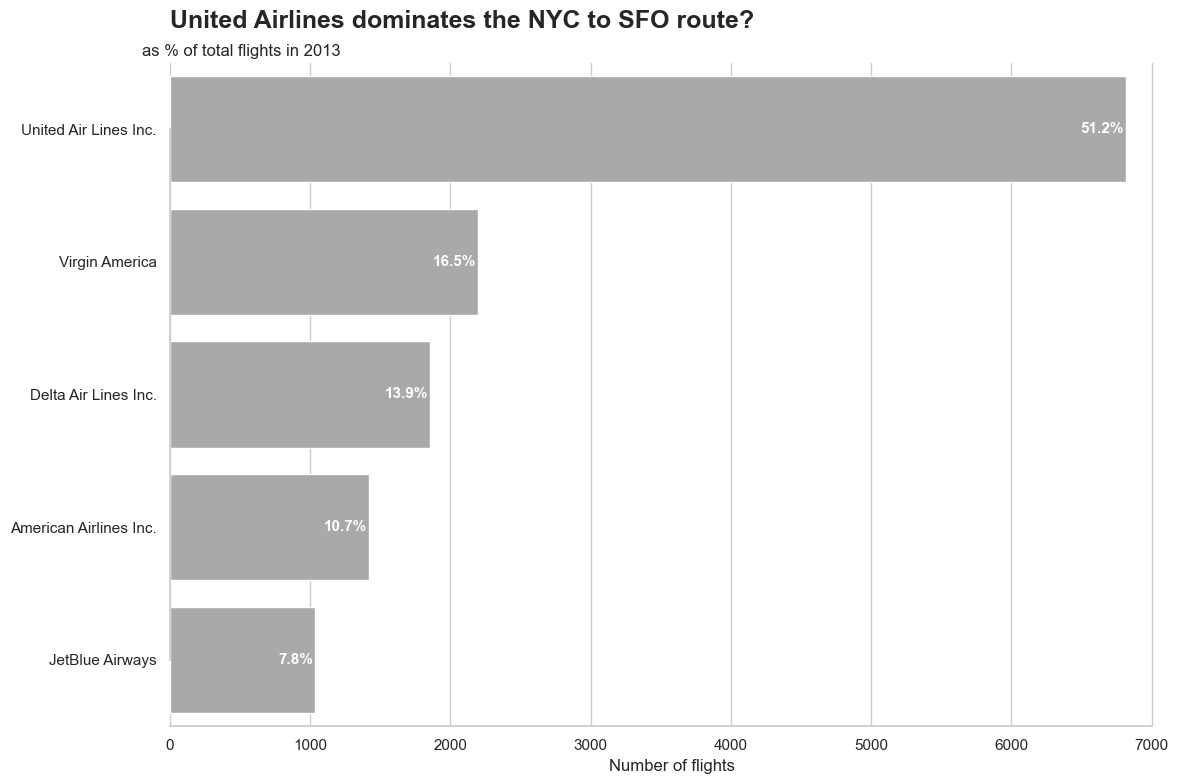

In [ ]:
# Calculate flights to SFO by carrier. Calucalte both the number and % for each airline, with the biggest ariline appearing at the top of your table/ barplot
fly_into_sfo = (

)

print(fly_into_sfo)

# 1. Prepare Data (Sorted Descending)
fly_into_sfo = (

)

# 2. Create Visualization
plt.figure(figsize=(12, 8))

# Use 'color' for uniform grey, and 'order' to ensure the sort is respected. 
ax = sns.barplot(

)

# 3. Add percentage labels
# We iterate through the patches (bars) and the dataframe rows simultaneously
for i, (p, pct) in enumerate(zip(ax.patches, fly_into_sfo['percent_str'])):
    width = p.get_width()
    # If the bar is too short, put the text outside in black; else, inside in white
    text_color = 'white' if width > 200 else 'black'
    ha_pos = 'right' if width > 200 else 'left'
    offset = -15 if width > 200 else 15
    
    ax.text(
        width + offset, 
        i, 
        pct, 
        va='center', 
        ha=ha_pos,
        color=text_color, 
        fontsize=11, 
        fontweight='bold'
    )

# 4. Styling & Titles
plt.title('United Airlines dominates the NYC to SFO route', 
          fontsize=18, fontweight='bold', loc='left', pad=25)
# Using fig.text for the subtitle to match your previous style but cleaner
plt.figtext(0.125, 0.92, 'as % of total flights in 2013', fontsize=12, ha='left')

plt.xlabel('Number of flights', fontsize=12)
plt.ylabel('') # Remove y-axis label for cleaner look

# Remove the top and right spines (borders)
sns.despine(trim=True)

plt.tight_layout()
plt.show()

## Problem 5: Cancellations to SFO

Explain how you would create a visualization showing SFO cancellations by month and carrier.

**Approach to create the cancellations plot:**

1. Filter flights for destination SFO and where `dep_time` is null (cancelled)
2. Group by `month` and `carrier`
3. Count cancellations for each combination
4. Join with airlines table to get full carrier names
5. Create a grouped bar chart or faceted plot using seaborn's `catplot` or `barplot`
6. Use month on x-axis, count on y-axis, and carrier as hue/color
7. Add appropriate labels and styling

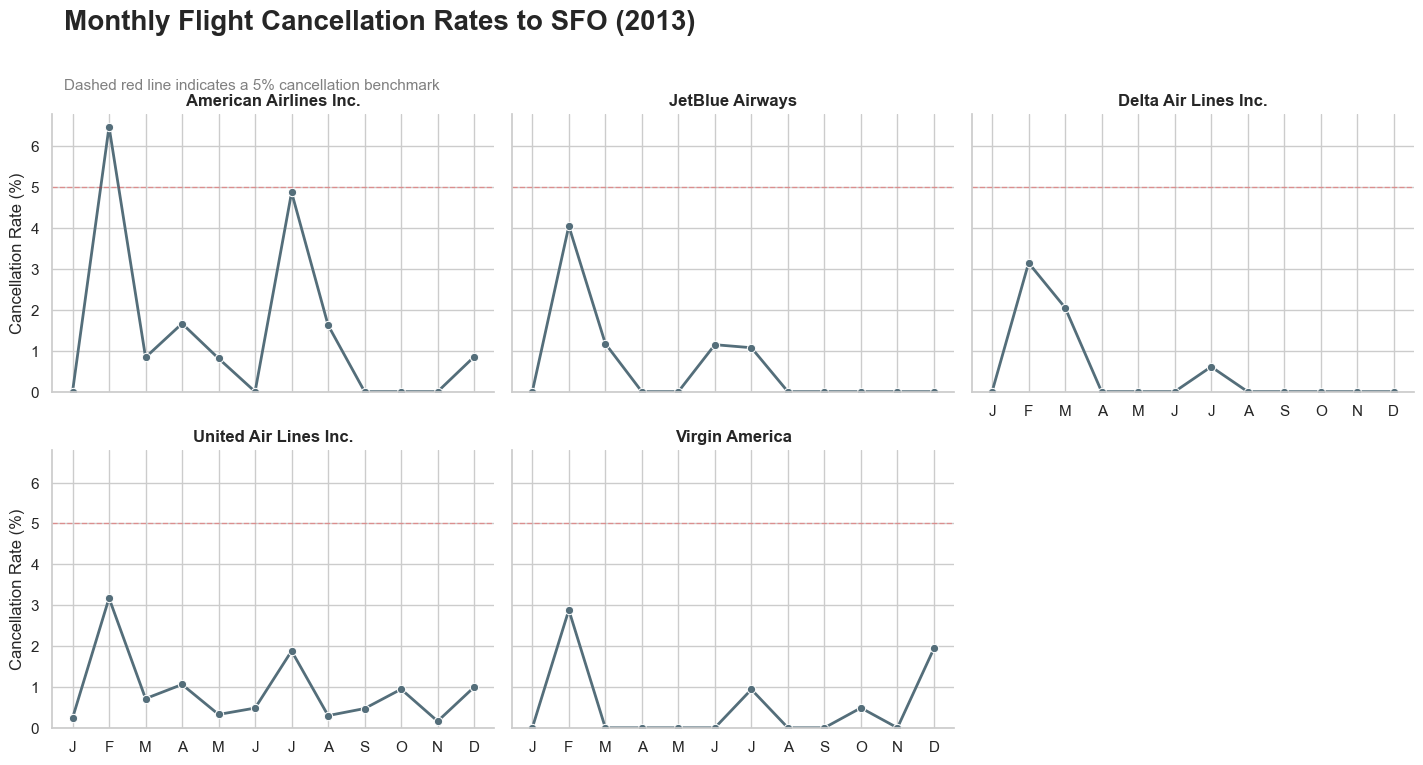

In [ ]:
# 1. PREPARE THE DATA
# Filter for SFO flights and create an 'is_cancelled' flag. I want to see arilines names, not codes, eg, United Airlines and not UA
sfo_stats = (

)

# Convert month numbers to names for the plot
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
sfo_stats['month_name'] = sfo_stats['month'].map(month_map)

# 2. VISUALIZATION
# We use a FacetGrid to see each airline clearly
g = sns.FacetGrid(
    data=sfo_stats, 
    col="name", 
    col_wrap=3, 
    height=4, 
    aspect=1.2
)

# Map a lineplot onto the grid
# Using a slate grey for the lines
g.map(sns.lineplot, "month", "cancel_pct", marker='o', color='#546E7A', linewidth=2)

# 3. STYLING & FORMATTING
g.set_titles("{col_name}", fontweight='bold', size=12)
g.set_axis_labels("", "Cancellation Rate (%)")

# Fix X-axis to show month names and set Y-axis to start at 0
for ax in g.axes.flatten():
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_ylim(0, None) # Start at 0, let top be dynamic
    # Add a light horizontal line at 5% as a benchmark
    ax.axhline(5, color='red', ls='--', alpha=0.3, linewidth=1)

# Main Title and Subtitle
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Monthly Flight Cancellation Rates to SFO (2013)', 
               fontsize=20, fontweight='bold', x=0.05, ha='left')

# Add a text annotation for the red line
g.fig.text(0.05, 0.88, "Dashed red line indicates a 5% cancellation benchmark", 
           fontsize=11, color='gray', ha='left')

plt.show()

# Problem 6: The Confounding Trap - Which Carrier is "Best"?

**Business Question**: Which carrier should we benchmark against?

**The Naive Approach**: Just rank carriers by average delay.

**The Problem**: Different carriers fly different routes! 🚨

In [ ]:
# Perform the join
flights_with_names = flights.merge(

)

print("AFTER JOIN:")
print(flights_with_names[['carrier', 'name', 'flight', 'origin', 'dest']].head())

# Naive analysis
carrier_delays = (flights_with_names

)

carrier_delays.columns = ['avg_arrival_delay', 'avg_departure_delay', 'num_flights']

print("⚠️  NAIVE RANKING (Don't trust this yet!):")
print("\nBest Carriers (lowest arrival delay):")
print(carrier_delays.head(10))

print("\nWorst Carriers (highest arrival delay):")
print(carrier_delays.tail(5))

AFTER JOIN:
  carrier                    name  flight origin dest
0      UA   United Air Lines Inc.    1545    EWR  IAH
1      UA   United Air Lines Inc.    1714    LGA  IAH
2      AA  American Airlines Inc.    1141    JFK  MIA
3      B6         JetBlue Airways     725    JFK  BQN
4      DL    Delta Air Lines Inc.     461    LGA  ATL
⚠️  NAIVE RANKING (Don't trust this yet!):

Best Carriers (lowest arrival delay):
                        avg_arrival_delay  avg_departure_delay  num_flights
name                                                                       
Alaska Airlines Inc.                -9.93                 5.80          714
Hawaiian Airlines Inc.              -6.92                 4.90          342
American Airlines Inc.               0.36                 8.59        32729
Delta Air Lines Inc.                 1.64                 9.26        48110
Virgin America                       1.76                12.87         5162
US Airways Inc.                      2.13         

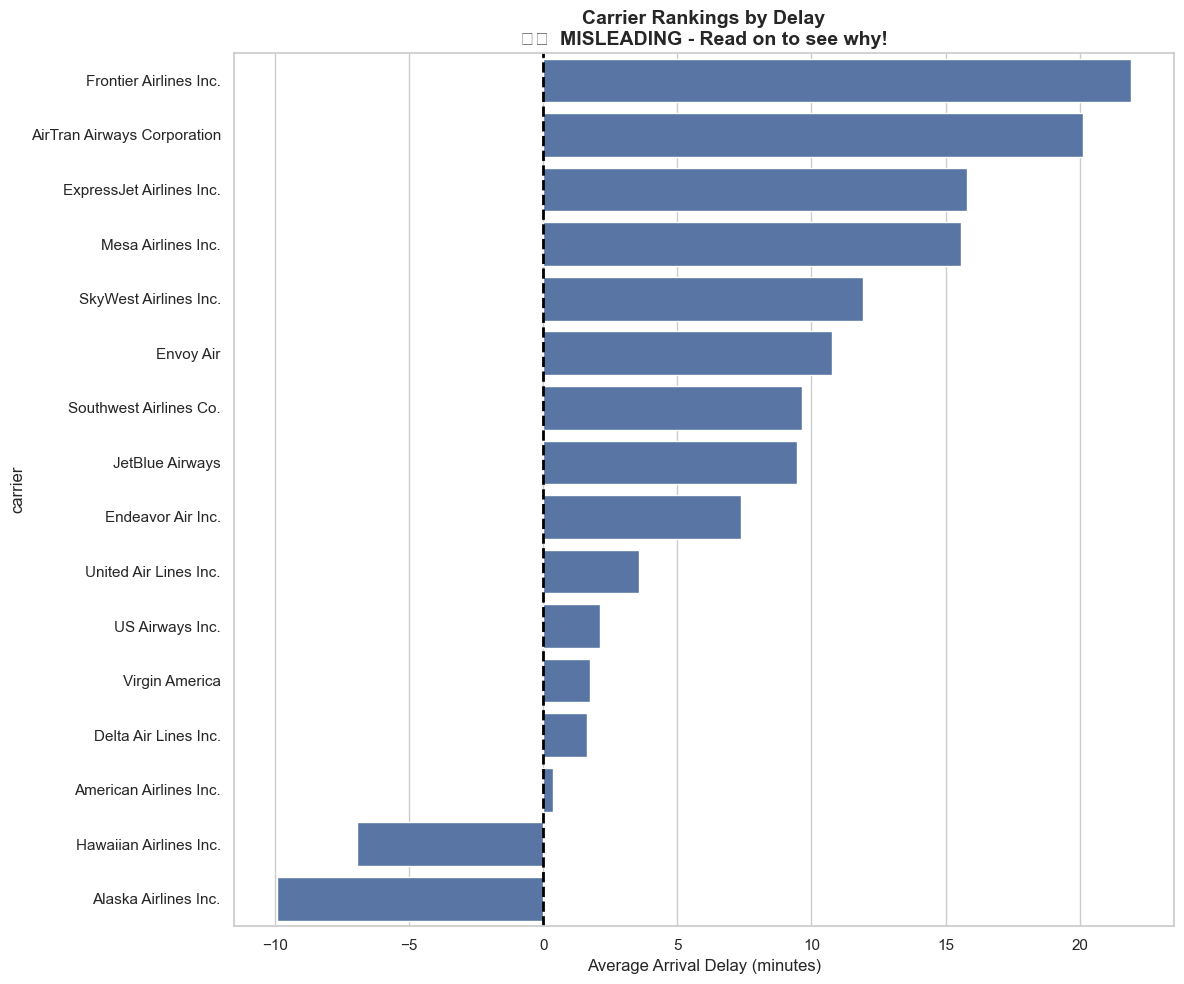

In [52]:
# Visualize
# Prepare data (assuming carrier_delays has 'carrier' and 'avg_arrival_delay')
carrier_delays_sorted = carrier_delays.sort_values('avg_arrival_delay', ascending=False)
carrier_delays_sorted['carrier'] = carrier_delays_sorted.index  # Ensure carrier column

# Color bars based on positive/negative delays (diverging palette)
plt.figure(figsize=(12, 10))
sns.barplot(data=carrier_delays_sorted, 
            y='carrier', 
            x='avg_arrival_delay',
            dodge=False,
            errorbar=None)  # No CIs

plt.xlabel('Average Arrival Delay (minutes)')
plt.title('Carrier Rankings by Delay\n⚠️  MISLEADING - Read on to see why!',
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

### 🤔 What's Wrong With This Analysis?

**Think about it**: 
- What if one carrier flies mostly to congested airports?
- What if another flies mostly short routes with good weather?
- Are we comparing apples to apples?

**The answer**: NO! We're confounding CARRIER PERFORMANCE with ROUTE DIFFICULTY.

Let's investigate...

---

# Problem 7: The Confounder Revealed - Route Difficulty

**Hypothesis**: Different routes have different inherent delay probabilities.

**Test**: Calculate average delay by route (origin-destination pair).

In [ ]:
# Calculate delay by route
route_delays = (flights

               )

route_delays.columns = ['origin', 'dest', 'avg_delay', 'avg_distance', 'num_flights']

# Filter for routes with enough data, say more than 50 flights
route_delays = route_delays[ ]

print("Most Delay-Prone Routes:")
print(route_delays.nlargest(10, 'avg_delay'))

print("\nLeast Delay-Prone Routes:")
print(route_delays.nsmallest(10, 'avg_delay'))

Most Delay-Prone Routes:
    origin dest  avg_delay  avg_distance  num_flights
13     EWR  CAE      44.59        602.00          104
84     EWR  TYS      41.15        631.00          323
82     EWR  TUL      33.66      1,215.00          315
53     EWR  OKC      30.62      1,325.00          346
65     EWR  RIC      25.82        277.00         1667
47     EWR  MKE      24.00        725.00         1094
23     EWR  DSM      23.55      1,017.00          411
48     EWR  MSN      23.20        799.00          354
63     EWR  PWM      23.01        284.00          770
101    JFK  CMH      22.92        483.00          742

Least Delay-Prone Routes:
    origin dest  avg_delay  avg_distance  num_flights
214    LGA  SAV     -10.51        722.00           68
77     EWR  SNA      -7.87      2,434.00          825
109    JFK  HNL      -6.92      4,983.00          342
153    JFK  STT      -6.37      1,623.00          333
25     EWR  EGE      -5.35      1,725.54          110
189    LGA  IND      -5.00    

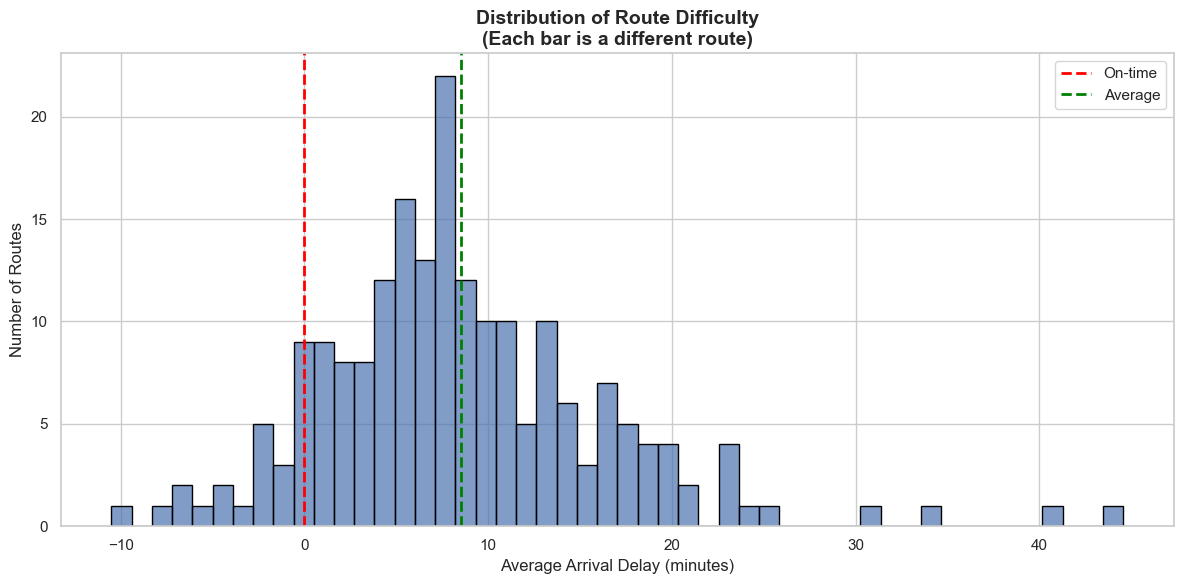


Route difficulty varies from -10.5 to 44.6 minutes!
Some routes are just HARDER than others.


In [ ]:
# Distribution of route difficulty
plt.figure(figsize=(12, 6))
sns.histplot(
    
)  
             

plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='On-time')
plt.axvline(x=route_delays['avg_delay'].mean(), color='green', 
           linestyle='--', linewidth=2, label='Average')

plt.title('Distribution of Route Difficulty\n(Each bar is a different route)',
         fontsize=14, fontweight='bold')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Number of Routes')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nRoute difficulty varies from {route_delays['avg_delay'].min():.1f} to {route_delays['avg_delay'].max():.1f} minutes!")
print("Some routes are just HARDER than others.")

In [ ]:
# Do carriers fly different route mixes?
# Join route difficulty back to flights
flights_with_route_difficulty = flights.merge(

).merge(airlines, on='carrier')  # Add carrier names

# Average route difficulty by carrier
carrier_route_mix = (flights_with_route_difficulty

                    )

carrier_route_mix.columns = ['avg_delay', 'avg_distance', 'num_flights']

print("\nAverage Route Difficulty by Carrier:")
print(carrier_route_mix)


Average Route Difficulty by Carrier:
                             avg_delay  avg_distance  num_flights
name                                                             
ExpressJet Airlines Inc.         14.35        562.99        54173
AirTran Airways Corporation      13.47        664.83         3260
Mesa Airlines Inc.               10.63        375.03          601
SkyWest Airlines Inc.             9.75        500.81           32
Southwest Airlines Co.            9.71        996.27        12275
Envoy Air                         8.98        569.53        26397
Endeavor Air Inc.                 8.92        530.24        18460
Frontier Airlines Inc.            7.85      1,620.00          685
JetBlue Airways                   6.43      1,068.62        54635
Delta Air Lines Inc.              5.53      1,236.90        48110
US Airways Inc.                   4.34        553.46        20536
United Air Lines Inc.             3.86      1,529.11        58665
American Airlines Inc.            1.51

### 🚨 THE BIG REVEAL:

**Different carriers fly systematically different routes!**

- Some carriers specialize in difficult routes (long distance, congested airports)
- Others fly easier routes
- **You cannot just compare raw delay averages!**

This is called **CONFOUNDING**. Carrier performance is **confounded** with route difficulty.

### 💡 Key Learning:
**Correlation ≠ Causation because of confounders!**

Just because Carrier A has higher delays doesn't mean they're worse—they might just fly harder routes!

---

# Problem 8: Weather Join - Introduction to Multi-Column Joins

**Business Question**: Does weather actually cause delays?

**Technical Challenge**: Weather is recorded by hour and airport. We need to match:
- Year
- Month  
- Day
- Hour
- Origin airport

This is a **multi-column join** (also called composite key join).

In [59]:
# The multi-column join
flights_weather = flights.merge(
    weather,
    on=['year', 'month', 'day', 'hour', 'origin'],  # Match on ALL these columns
    how='left'  # Keep all flights, add weather where available
)

print("JOIN RESULTS:")
print(f"  Original flights: {len(flights):,}")
print(f"  After join: {len(flights_weather):,}")
print(f"  Flights with weather data: {flights_weather['temp'].notna().sum():,}")
print(f"  Missing weather: {flights_weather['temp'].isna().sum():,}")

print("\nSample of joined data:")
flights_weather[['origin', 'dest', 'dep_delay', 'temp', 'precip', 'visib']].head(10)

JOIN RESULTS:
  Original flights: 336,776
  After join: 336,776
  Flights with weather data: 335,203
  Missing weather: 1,573

Sample of joined data:


,origin,dest,dep_delay,temp,precip,visib
0,EWR,IAH,2.00,39.02,0.00,10.00
1,LGA,IAH,4.00,39.92,0.00,10.00
2,JFK,MIA,2.00,39.02,0.00,10.00
3,JFK,BQN,-1.00,39.02,0.00,10.00
4,LGA,ATL,-6.00,39.92,0.00,10.00
5,EWR,ORD,-4.00,39.02,0.00,10.00
6,EWR,FLL,-5.00,37.94,0.00,10.00
7,LGA,IAD,-3.00,39.92,0.00,10.00
8,JFK,MCO,-3.00,37.94,0.00,10.00
9,LGA,ORD,-2.00,39.92,0.00,10.00


### Why LEFT join instead of INNER?

- **INNER join**: Only keeps flights where we have weather data
- **LEFT join**: Keeps ALL flights, adds weather where available

We use LEFT because:
1. Flights are our primary data
2. We want to know if weather data is missing (that's informative!)
3. Can always filter later

---

In [ ]:
# Analyze weather impact - what happens for flights where `precip>0` (when it rains)

# Precipitation
flights_weather['has_precip'] = .......
precip_impact = (flights_weather

                )

print("Delay with/without Precipitation:")
print(precip_impact)

Delay with/without Precipitation:
   has_precip  dep_delay  arr_delay  flight
0       False      11.38       5.07  313774
1        True      30.93      33.54   23002


In [ ]:
# Visibility bins # Analyze weather impact with visibility- what happens for flights where visibility is excellent (0-2), good (2-5), fair (5-10), and excellent (10-15)? 
# create a new variable visibility_category, by using pd.cut()

flights_weather['visibility_category'] = pd.cut(

)

vis_impact = (flights_weather


             )

print("\nDelay by Visibility:")
print(vis_impact)


Delay by Visibility:
  visibility_category  dep_delay  arr_delay  flight
0                Poor      27.94      32.80   10594
1                Fair      20.87      19.98   13120
2                Good      11.81       5.53  311396
3           Excellent        NaN        NaN       0


DO the same for temperature ((pd.cut temperatures every 10 degree)) and for wind speed (use 8 bins)

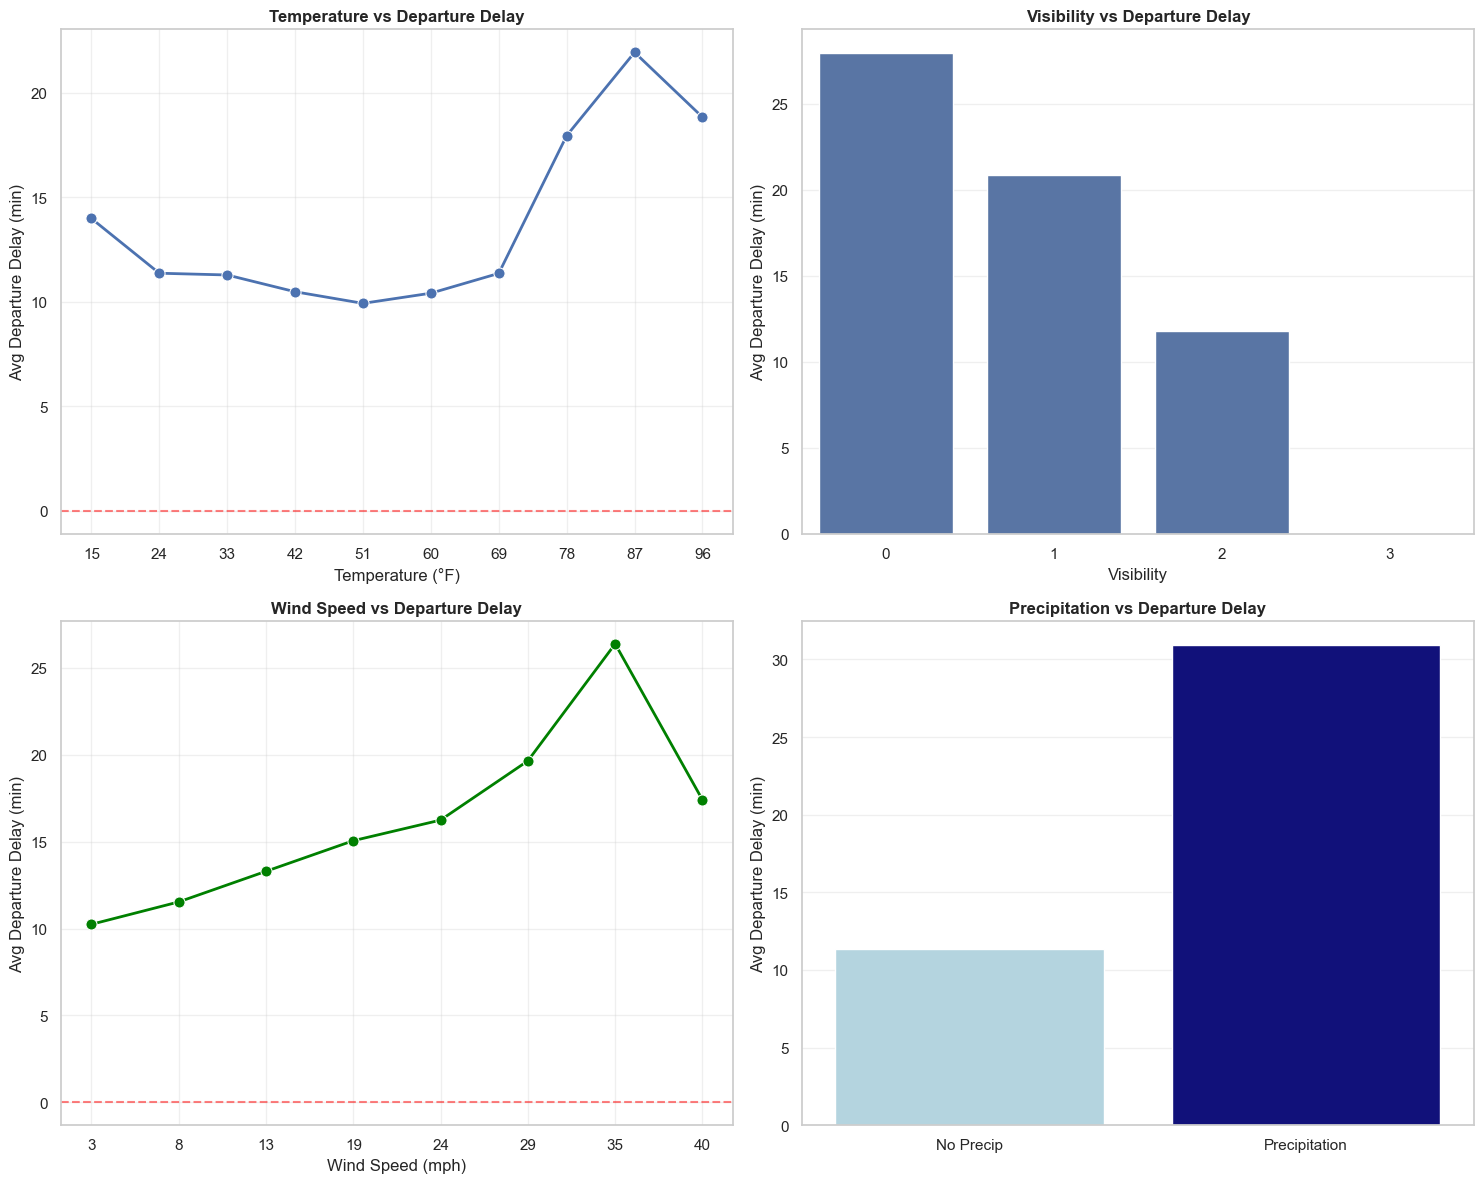

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Temperature vs delay
temp_bins =  
temp_delay =  
x_labels_temp = [f"{interval.mid:.0f}" for interval in temp_delay.index]
sns.lineplot(
    
)
axes[0, 0].set_title('Temperature vs Departure Delay', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Temperature (°F)')
axes[0, 0].set_ylabel('Avg Departure Delay (min)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Visibility vs delay

axes[0, 1].set_title('Visibility vs Departure Delay', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Visibility')
axes[0, 1].set_ylabel('Avg Departure Delay (min)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Wind speed
wind_bins =  
wind_delay =  
x_labels_wind =  
sns.lineplot(
    
)
axes[1, 0].set_title('Wind Speed vs Departure Delay', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Wind Speed (mph)')
axes[1, 0].set_ylabel('Avg Departure Delay (min)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Precipitation

axes[1, 1].set_title('Precipitation vs Departure Delay', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Avg Departure Delay (min)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 🌤️ Weather Insights

Yes, weather CORRELATES with delays. But can we say weather CAUSES delays?

**Potential confounders**:
- Bad weather often happens in winter → winter has holiday travel → more congestion
- Bad weather → some flights cancelled → we only see flights that flew (selection bias!)
- Temperature extremes → different times of year → seasonal route changes

**The lesson**: Even an obvious relationship (weather → delays) has confounders!

---

# Problem 9: Simpson's Paradox - Time of Day

**The Setup**: Early morning flights tend to have shorter delays.

**The Question**: Is this true for ALL carriers?

**The Surprise**: The pattern can REVERSE when you look at subgroups!

In [ ]:
# Create time of day categories
# flights['hour'] = flights['sched_dep_time'] // 100

flights['time_of_day'] = pd.cut(


)

# Overall pattern
time_delays = (
    
)

print("OVERALL: Delay by Time of Day")
print(time_delays)
print("\n✅ Clear pattern: Later flights have more delays")

OVERALL: Delay by Time of Day
             dep_delay  flight
time_of_day                   
Night             1.58   27905
Morning           5.19  121297
Afternoon        17.34  134761
Evening          23.99   52813

✅ Clear pattern: Later flights have more delays


In [ ]:
# Get carrier names from nycflights13 airlines table

flights['time_of_day'] = pd.cut(
    
)

carrier_time = (
    
)

top_5_carriers = flights['carrier'].value_counts().head(5).index
carrier_time_top5 = carrier_time[carrier_time['carrier'].isin(top_5_carriers)].copy()

# Join to get full carrier names
carrier_time_top5 = carrier_time_top5.merge(
    airlines[['carrier', 'name']], on='carrier', how='left'
)

# Ensure time_of_day is a string
carrier_time_top5['time_of_day'] = carrier_time_top5['time_of_day'].astype(str)

print("\nBY CARRIER: Delay by Time of Day (Top 5 carriers)")
print(carrier_time_top5)


BY CARRIER: Delay by Time of Day (Top 5 carriers)
   carrier time_of_day  dep_delay  flight                      name
0       AA       Night      -0.80    2918    American Airlines Inc.
1       AA     Morning       2.81   12845    American Airlines Inc.
2       AA   Afternoon      13.64   14030    American Airlines Inc.
3       AA     Evening      19.34    2936    American Airlines Inc.
4       B6       Night       0.51    5092           JetBlue Airways
5       B6     Morning       4.25   18052           JetBlue Airways
6       B6   Afternoon      17.96   19024           JetBlue Airways
7       B6     Evening      23.35   12467           JetBlue Airways
8       DL       Night      -0.53    2253      Delta Air Lines Inc.
9       DL     Morning       2.60   19137      Delta Air Lines Inc.
10      DL   Afternoon      13.43   19819      Delta Air Lines Inc.
11      DL     Evening      18.98    6901      Delta Air Lines Inc.
12      EV       Night       5.42    4926  ExpressJet Airlines In

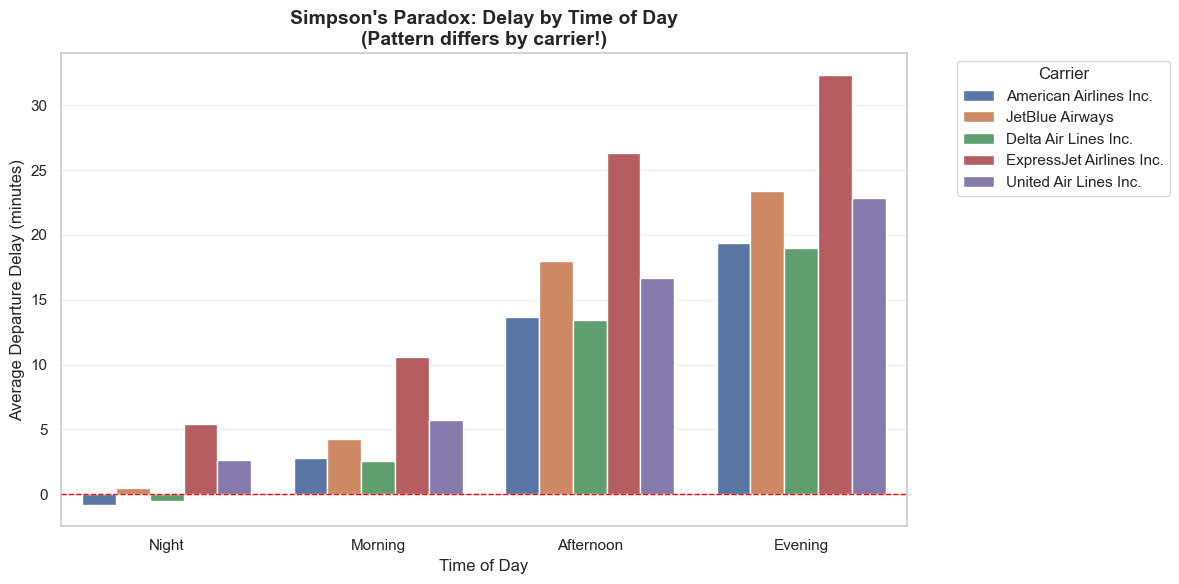

In [ ]:
# Visualize the paradox
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    
)
ax.set_title("Simpson's Paradox: Delay by Time of Day\n(Pattern differs by carrier!)",
             fontsize=14, fontweight='bold')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Average Departure Delay (minutes)')
ax.legend(title='Carrier', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()  

### 🎭 SIMPSON'S PARADOX EXPLAINED

**Overall**: Later = more delays  
**By carrier**: Pattern varies!

**Why does this happen?**
- Different carriers have different route mixes at different times
- Different operational strategies
- Different aircraft types

**The lesson**: 
**ALWAYS check if aggregate patterns hold within subgroups!**

A pattern that's true "on average" might not be true for ANY individual group.

---

# Question 10: Arrival vs Departure Delay

**Business Question**: Should we focus on departure or arrival performance?

**The Trap**: Arrival delay is confounded by flight time!

**Why?** Longer flights have more time to make up delays in the air.

In [97]:
# Remove cancelled flights
valid_flights = flights.dropna(subset=['dep_delay', 'arr_delay', 'air_time'])

# Calculate how much delay was recovered
valid_flights['delay_recovered'] = valid_flights['dep_delay'] - valid_flights['arr_delay']

print("Delay Recovery:")
print(f"  Average departure delay: {valid_flights['dep_delay'].mean():.2f} minutes")
print(f"  Average arrival delay: {valid_flights['arr_delay'].mean():.2f} minutes")
print(f"  Average recovered: {valid_flights['delay_recovered'].mean():.2f} minutes")

Delay Recovery:
  Average departure delay: 12.56 minutes
  Average arrival delay: 6.90 minutes
  Average recovered: 5.66 minutes


In [102]:
# Does recovery vary by flight duration?
valid_flights['duration_category'] = pd.cut(
    valid_flights['air_time'],
    bins=[0, 60, 120, 180, 360],
    labels=['Very Short (<1hr)', 'Short (1-2hr)', 'Medium (2-3hr)', 'Long (3hr+)']
)

recovery_by_duration = (valid_flights
                       .groupby('duration_category')
                       .agg({
                           'dep_delay': 'mean',
                           'arr_delay': 'mean',
                           'delay_recovered': 'mean',
                           'air_time': 'mean'
                       })
                       .round(2)
                       .reset_index())

print("\nDelay Recovery by Flight Duration:")
print(recovery_by_duration)


Delay Recovery by Flight Duration:
   duration_category  dep_delay  arr_delay  delay_recovered  air_time
0  Very Short (<1hr)      12.83       7.82             5.01     44.37
1      Short (1-2hr)      13.77       8.63             5.14     93.93
2     Medium (2-3hr)      12.52       7.61             4.91    145.54
3        Long (3hr+)      11.16       2.91             8.24    273.05


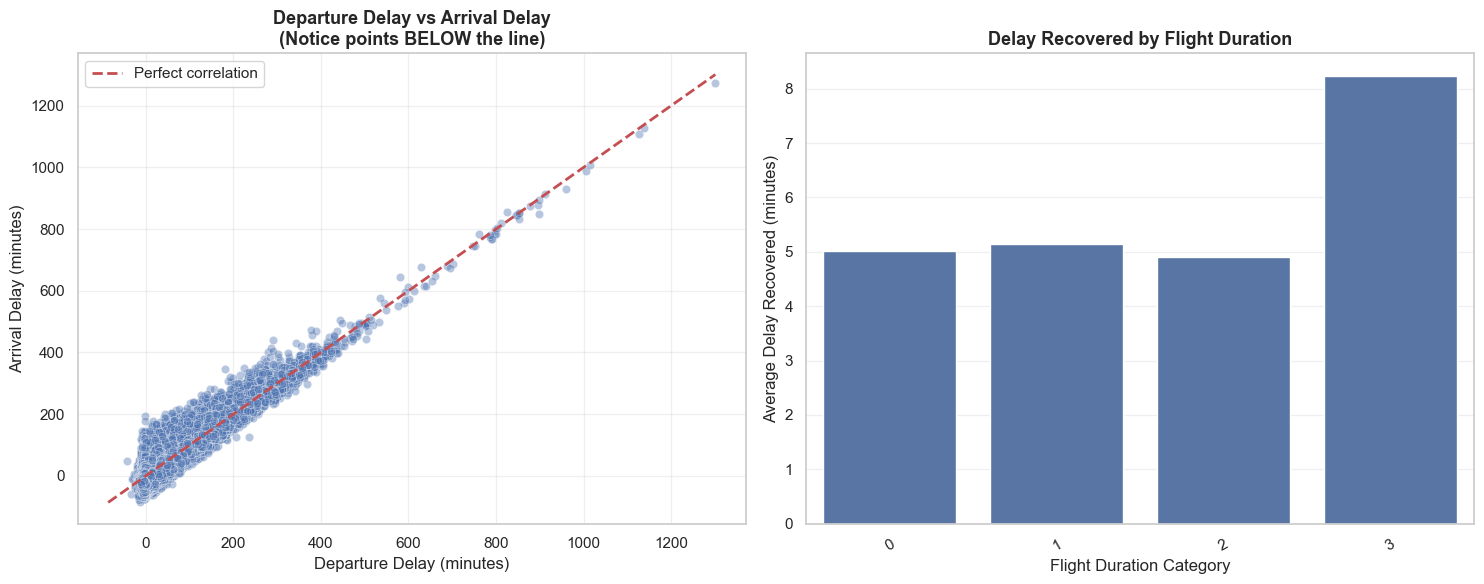

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Departure vs arrival delay
sns.scatterplot(data=flights, 
    x='dep_delay', 
    y='arr_delay', 
    alpha=0.4, 
    ax=axes[0]
)

# Extend line to cover full data range
min_val = min(flights['dep_delay'].min(), flights['arr_delay'].min())
max_val = max(flights['dep_delay'].max(), flights['arr_delay'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect correlation')

axes[0].set_title('Departure Delay vs Arrival Delay\n(Notice points BELOW the line)',
                 fontsize=13, fontweight='bold')
axes[0].set_xlabel('Departure Delay (minutes)')
axes[0].set_ylabel('Arrival Delay (minutes)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Recovery by duration
sns.barplot(x=recovery_by_duration.index, y=recovery_by_duration['delay_recovered'], ax=axes[1])
axes[1].set_title('Delay Recovered by Flight Duration', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Flight Duration Category')
axes[1].set_ylabel('Average Delay Recovered (minutes)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### ✈️ THE CONFOUNDER:

**Longer flights make up delays in the air!**

- Short flight delayed 20 min → probably arrives 20 min late
- Long flight delayed 20 min → might arrive only 10 min late

**The trap**:  
If you rank carriers by ARRIVAL delay, you're biased toward carriers that fly LONGER routes!

**The lesson**:  
Arrival delay and departure delay measure different things. Flight duration is a confounder.

---

# Question 11: Plane Age - Another Join, Another Confounder

**Business Question**: Do older planes cause more delays?

**Technical Skill**: Joining the planes table

**Critical Thinking**: Even if we find a correlation, can we claim causation?

JOIN DIAGNOSTICS:
  Original flights: 336,776
  After join: 336,776
  Flights with plane data: 278,864
  Missing plane data: 57,912

Delay by Plane Age:
           dep_delay  arr_delay  flight
plane_age                              
0-5yr          11.95       4.98   41605
5-10yr         14.91       9.41   73647
10-15yr        13.66       7.89  109568
15-20yr        11.33       3.24   15257
20+yr          10.65       3.90   34018

Delay by Plane Age:
           dep_delay  arr_delay  flight
plane_age                              
0-5yr          11.95       4.98   41605
5-10yr         14.91       9.41   73647
10-15yr        13.66       7.89  109568
15-20yr        11.33       3.24   15257
20+yr          10.65       3.90   34018


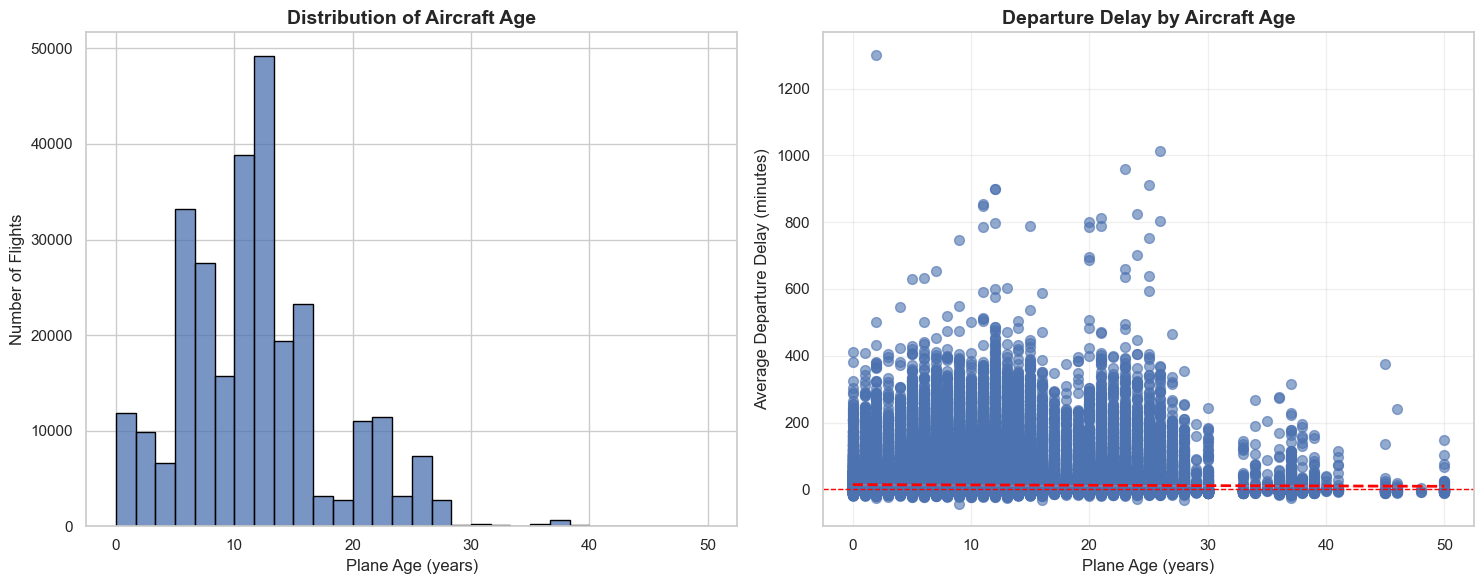


Correlation: -0.015


In [ ]:
# Join planes data
flights_planes = flights.merge(


)

print(f"JOIN DIAGNOSTICS:")
print(f"  Original flights: {len(flights):,}")
print(f"  After join: {len(flights_planes):,}")
print(f"  Flights with plane data: {flights_planes['year_manufactured'].notna().sum():,}")
print(f"  Missing plane data: {flights_planes['year_manufactured'].isna().sum():,}")

# Calculate plane age
flights_planes['plane_age'] = 

# Remove unrealistic ages
flights_planes_clean = flights_planes[

]

# Delay by age - cut into 0,5,10,15,20,50 year bins
age_bins = pd.cut(
    
)

delay_by_age = (
    
)

print("\nDelay by Plane Age:")
print(delay_by_age)

print("\nDelay by Plane Age:")
print(delay_by_age)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Distribution → sns.histplot
sns.histplot(

)
axes[0].set_title('Distribution of Aircraft Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Plane Age (years)')
axes[0].set_ylabel('Number of Flights')

# 2. Scatter + trend → sns.regplot (auto trendline + CI)
sns.regplot(
    
)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Departure Delay by Aircraft Age', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Plane Age (years)')
axes[1].set_ylabel('Average Departure Delay (minutes)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation ()
corr = flights_planes_clean[['plane_age', 'dep_delay']].corr().iloc[0, 1]
print(f"\nCorrelation: {corr:.3f}")



### 🤔 CRITICAL THINKING EXERCISE

Even if there IS a correlation between plane age and delays, can we say:

**"Old planes CAUSE delays"?**

**Potential confounders**:
1. Older planes fly different routes?
2. Older planes operated by different carriers with different maintenance?
3. Older planes used for different purposes (cargo vs passenger)?
4. Selection bias: Really bad old planes already retired?

**What would you need to make a causal claim?**
- Randomized experiment (impossible)
- Control for route, carrier, season, etc.
- Understand maintenance differences

**The lesson**: Even strong correlations don't prove causation!

# Question 12: Statistical vs Practical Significance

**Business Question**: Which NYC airport should we operate from?

**The Trap**: With enough data, TINY differences become "statistically significant"

**But**: Are they PRACTICALLY significant?

In [10]:
# Compare the three NYC airports
airport_delays = (flights
                 .groupby('origin')
                 .agg({
                     'dep_delay': ['mean', 'std', 'count'],
                     'arr_delay': ['mean', 'std', 'count']
                 })
                 .round(2)
                 .reset_index()
)
print("Delay Statistics by Airport:")
print(airport_delays)

# Pairwise t-tests on raw data
from itertools import combinations
from scipy import stats

origins = ['EWR', 'JFK', 'LGA']
pairs = list(combinations(origins, 2))

t_results = []
for orig1, orig2 in pairs:
    group1 = flights.loc[flights['origin'] == orig1, 'dep_delay'].dropna()
    group2 = flights.loc[flights['origin'] == orig2, 'dep_delay'].dropna()
    
    mean1, mean2 = group1.mean(), group2.mean()
    delta = round(mean1 - mean2, 2)
    
    stat, pval = stats.ttest_ind(group1, group2, equal_var=False)
    t_results.append({
        'pair': f"{orig1}-{orig2}",
        'delta_min': delta,  # EWR-JFK: positive = EWR higher
        't_stat': round(stat, 3),
        'p_value': f"{pval:.1e}",
        'n1': f"{len(group1):,}",
        'n2': f"{len(group2):,}"
    })

results_df = pd.DataFrame(t_results)
print("\nPairwise Welch's t-tests (dep_delay):")
print(results_df)


Delay Statistics by Airport:
  origin dep_delay               arr_delay              
              mean   std   count      mean   std   count
0    EWR     15.11 41.32  117596      9.11 45.53  117127
1    JFK     12.11 39.04  109416      5.55 44.28  109079
2    LGA     10.35 39.99  101509      5.78 43.86  101140

Pairwise Welch's t-tests (dep_delay):
      pair  delta_min  t_stat   p_value       n1       n2
0  EWR-JFK       3.00   17.76   1.6e-70  117,596  109,416
1  EWR-LGA       4.76   27.36  1.5e-164  117,596  101,509
2  JFK-LGA       1.77   10.25   1.2e-24  109,416  101,509


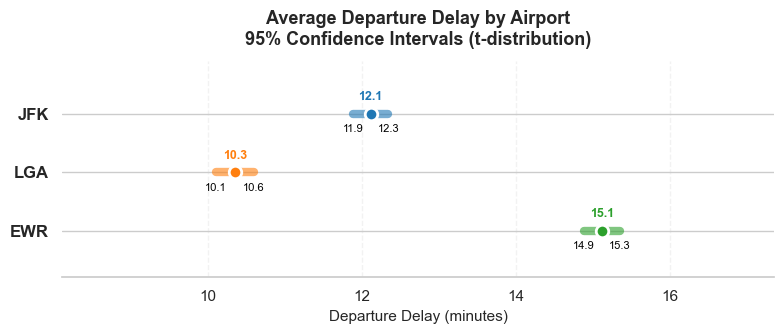

In [11]:
# Visualisation as CI with error bars
airport_stats = (flights.groupby('origin')['dep_delay']
                 .agg(['mean', 'std', 'count'])
                 .round(2))

airport_stats['se'] = airport_stats['std'] / np.sqrt(airport_stats['count'])
airport_stats['t_crit'] = airport_stats['count'].apply(lambda n: stats.t.ppf(0.975, n - 1))
airport_stats['ci_lower'] = airport_stats['mean'] - airport_stats['t_crit'] * airport_stats['se']
airport_stats['ci_upper'] = airport_stats['mean'] + airport_stats['t_crit'] * airport_stats['se']

AIRPORTS = ['EWR', 'LGA', 'JFK']
COLORS = {'JFK': '#1f77b4', 'LGA': '#ff7f0e', 'EWR': '#2ca02c'}

fig, ax = plt.subplots(figsize=(8, 3.5))

for i, origin in enumerate(AIRPORTS):
    row = airport_stats.loc[origin]
    color = COLORS[origin]
    ax.hlines(y=[i], xmin=[row['ci_lower']], xmax=[row['ci_upper']],
              color=color, linewidth=6, alpha=0.6, capstyle='round')
    ax.plot(row['mean'], i, 'o', color=color, markersize=9,
            markeredgecolor='white', markeredgewidth=2, zorder=5)
    # Mean label above
    ax.text(row['mean'], i + 0.18, f"{row['mean']:.1f}",
            ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')
    # Lower/upper labels below
    ax.text(row['ci_lower'], i - 0.18, f"{row['ci_lower']:.1f}",
            ha='center', va='top', fontsize=8, color='black')
    ax.text(row['ci_upper'], i - 0.18, f"{row['ci_upper']:.1f}",
            ha='center', va='top', fontsize=8, color='black')

ax.set_yticks(range(len(AIRPORTS)))
ax.set_yticklabels(AIRPORTS, fontsize=12, fontweight='bold')
ax.set_xlabel('Departure Delay (minutes)', fontsize=11)
ax.set_title('Average Departure Delay by Airport\n95% Confidence Intervals (t-distribution)',
             fontsize=13, fontweight='bold', pad=12)

ax.grid(True, alpha=0.25, axis='x', linestyle='--')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(airport_stats['ci_lower'].min() - 2, airport_stats['ci_upper'].max() + 2)
ax.set_ylim(-0.8, len(AIRPORTS) - 0.5 + 0.4)

plt.tight_layout()
plt.show()



### 📊 STATISTICAL vs PRACTICAL SIGNIFICANCE

**The numbers**:
- Sample sizes: >100,000 flights per airport
- Differences: 1-3 minutes

**Statistical significance**:  
With this much data, a 1-minute difference IS statistically significant (p < 0.05).

**Practical significance**:  
Is 1-2 minutes meaningful?
- Would YOU change airports to save 2 minutes?
- What's the cost of switching airports?
- What about convenience, accessibility, lounge access?

**The lesson**:  
**Large datasets make everything "significant"**. Always ask: "So what? Does this matter?"  

---

# Question 13: What's the "Best" Airport?

**The Insight**: "Best" depends on what you optimize for!

Different metrics give different answers.

In [ ]:
# Calculate multiple performance metrics
# First, define cancelled indicator in the flights DataFrame
flights['cancelled'] = flights['dep_time'].isna().astype(int)

# Then compute airport performance



# Different winners for different criteria!
print("\n🏆 RANKINGS:")
print(f"\nBest by Departure Delay: {airport_performance['avg_dep_delay'].idxmin()}")
print(f"Best by Arrival Delay: {airport_performance['avg_arr_delay'].idxmin()}")
print(f"Best by Cancellation Rate: {airport_performance['cancel_rate'].idxmin()}")
print(f"Most Flights (network): {airport_performance['num_flights'].idxmax()}")

Airport Performance - Multiple Dimensions:
        avg_dep_delay  avg_arr_delay  num_flights  avg_distance  \
origin                                                            
EWR             15.11           9.11       120835       1056.74   
JFK             12.11           5.55       111279       1266.25   
LGA             10.35           5.78       104662        779.84   

        median_distance  num_cancelled  cancel_rate  
origin                                               
EWR               872.0           3239         2.68  
JFK              1069.0           1863         1.67  
LGA               762.0           3153         3.01  

🏆 RANKINGS:

Best by Departure Delay: LGA
Best by Arrival Delay: JFK
Best by Cancellation Rate: JFK
Most Flights (network): EWR


---

# HW 2 Big Picture: What Did We Learn?

## 🎯 Critical Thinking Lessons

### 1️⃣ CONFOUNDING VARIABLES
**What it is**: A third variable that affects both X and Y, making it look like X causes Y.

**Examples we saw**:
- Carrier performance confounded by route difficulty
- Arrival delay confounded by flight duration  
- Destination delay confounded by distance

**Always ask**: "What else could explain this pattern?"

---

### 2️⃣ SELECTION BIAS
**What it is**: The data you observe isn't representative because of systematic missingness.

**Example we saw**:
- We only see delays for flights that flew
- Cancelled flights (worst weather) don't show up in delay stats
- This is "survivor bias" - only seeing survivors

**Always ask**: "What's missing from my data? Is it missing randomly?"

---

### 3️⃣ SIMPSON'S PARADOX
**What it is**: An aggregate pattern that reverses in subgroups.

**Example we saw**:
- Overall: Later flights = more delays
- By carrier: Pattern varies!

**Always ask**: "Does this hold across subgroups?"

---

### 4️⃣ STATISTICAL vs PRACTICAL SIGNIFICANCE
**What it is**: With large data, tiny differences become "statistically significant" but may not matter.

**Example we saw**:
- 1-2 minute difference between airports
- Statistically significant (p < 0.05)
- Practically irrelevant (who cares about 1 minute?)

**Always ask**: "So what? Does this matter in practice?"

---

### 5️⃣ NON-INDEPENDENCE
**What it is**: Observations aren't independent - they affect each other.

**Example we saw**:
- Delays cascade throughout the day
- Same aircraft, same crew, same gates

**Always ask**: "Are these observations truly independent?"

---

## 🔧 Technical Skills: Joining Data

### What You Learned:

**Simple joins**:
```python
df1.merge(df2, on='key', how='left')
```

**Multi-column joins**:
```python
df1.merge(df2, on=['col1', 'col2', 'col3'], how='left')
```

**Multiple sequential joins**:
```python
result = (df1
         .merge(df2, on='key1')
         .merge(df3, on='key2')
         .merge(df4, on='key3'))
```

**Handling name conflicts**:
```python
.merge(df2, suffixes=('_left', '_right'))
```

**Join diagnostics**:
- Always check row counts before/after
- Check for unexpected NaN values
- Verify sample rows look correct

---

## 💡 What Makes You Valuable

**In a world where AI can write the joins, YOUR value is:**

1. **Knowing what confounders to check for**
   - AI can write `groupby().mean()` 
   - You know to check if the groups are comparable

2. **Recognizing when patterns are misleading**
   - AI can find correlations
   - You know when they're spurious

3. **Understanding what's missing**
   - AI can analyze present data
   - You notice systematic missingness

4. **Asking better questions**
   -  AI can answer the question you ask
   - You know which questions are worth asking

5. **Knowing when you CAN'T make causal claims**
   - AI can find relationships
   - You know when they're unactionable

---

## 🎓 Critical Thinking Checklist

Before trusting ANY analysis, ask:

- [ ] **Confounders**: What else could explain this pattern?
- [ ] **Selection bias**: What data am I not seeing?
- [ ] **Subgroups**: Does this hold for all segments?
- [ ] **Practical significance**: Does this difference matter?
- [ ] **Independence**: Are observations actually independent?
- [ ] **Causation**: Can I actually claim X causes Y?
- [ ] **Alternative explanations**: What else could it be?


Challenges: You have to recreate one of the two challenges below.

1. Plotting the risk-return tradeoff for a selected set of assets for each of the last few years
2. Plotting a graph when the US yield curve inverted (when the 3month T-Bill yields more than the 10 year bond) and whether inversions predict recessions

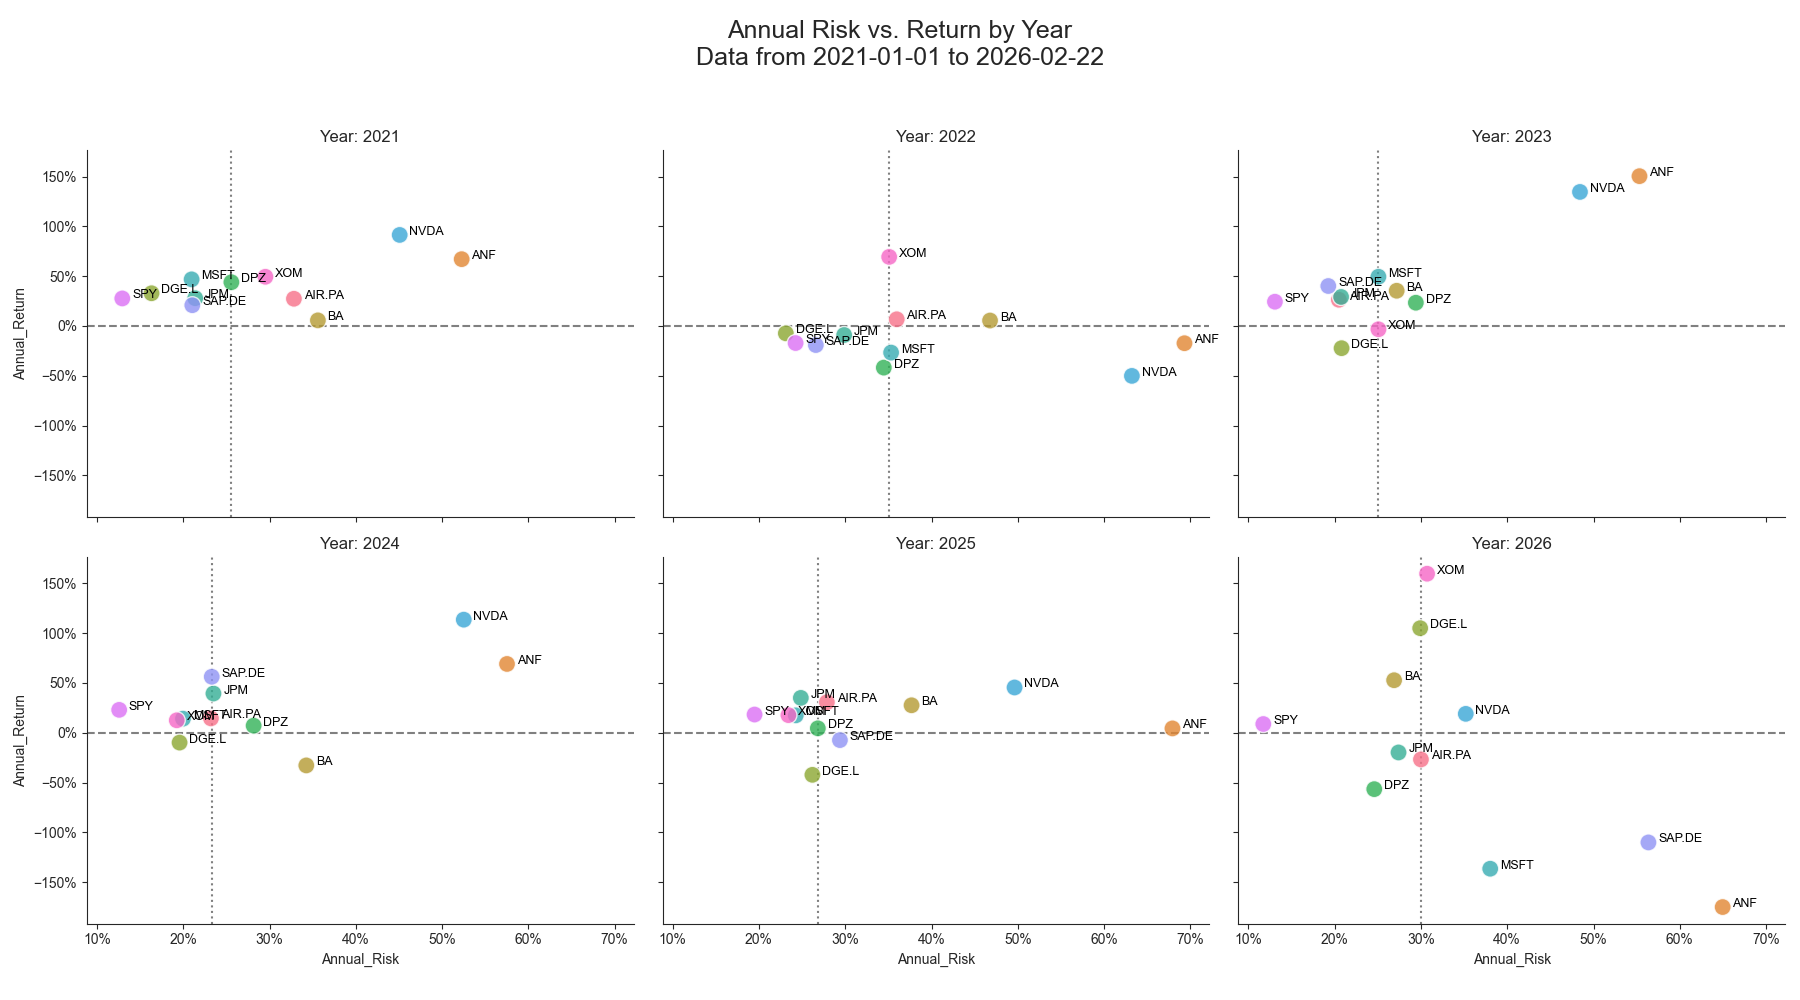

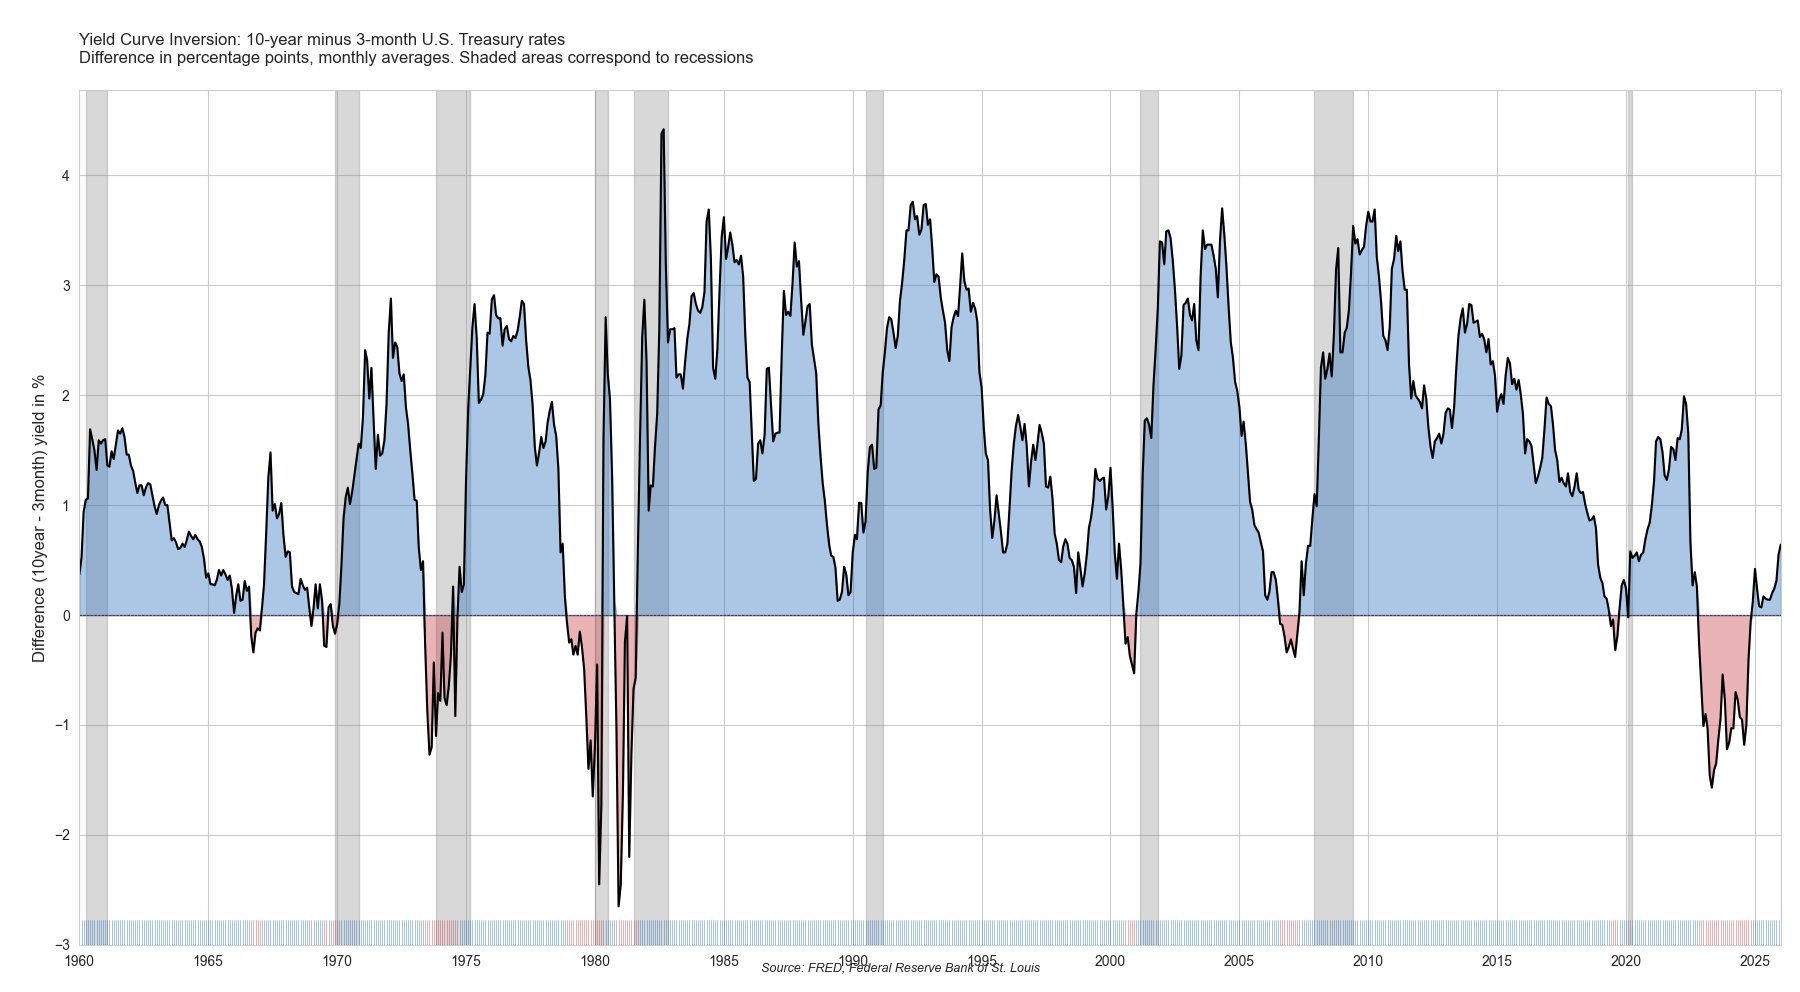

In [3]:

from IPython.display import Image, display
display(Image(filename='risk_return_by_year.png'))
display(Image(filename='yield_curve_inversions.png'))

In [ ]:
# Code to download stock data for challenge 1

import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date

# =============================================================================
# 1. SETUP AND DATA DOWNLOAD
# =============================================================================
tickers = ['SPY', 'NVDA', 'AIR.PA', 'MSFT', 'BA', 'JPM', 'XOM','DGE.L','ANF','DPZ', 'SAP.DE']

# Dynamically set the date range for the last 5 full years
end_date = date.today()
start_date = date(end_date.year - 5, 1, 1)
sns.set_style("ticks")

print(f"Downloading historical stock data from {start_date} to {end_date}...")
adj_close_df = yf.download(tickers,
                           start=start_date,
                           end=end_date,
                           auto_adjust=False)['Adj Close']

print("\n--- Downloaded Data (First 10 Rows) ---")
print(adj_close_df.head(10))

In [ ]:
# risk-return by year   


In [ ]:
# Code to download yield curve data for challenge 2

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import datetime

# --- Data Preparation ---

# Get a list of FRED codes for US rates and US yield curve; choose monthly frequency
tickers = [
    "TB3MS",  # 3-month Treasury bill (or T-bill) https://fred.stlouisfed.org/series/TB3MS
    "TB6MS",  # 6-month
    "GS1",  # 1-year
    "GS2",  # 2-year, etc....
    "GS3",
    "GS5",
    "GS7",
    "GS10",
    "GS20",
    "GS30",  # .... all the way to the 30-year rate
]

# Turn FRED codes to human readable variables
myvars = [
    "3-Month Treasury Bill",
    "6-Month Treasury Bill",
    "1-Year Treasury Rate",
    "2-Year Treasury Rate",
    "3-Year Treasury Rate",
    "5-Year Treasury Rate",
    "7-Year Treasury Rate",
    "10-Year Treasury Rate",
    "20-Year Treasury Rate",
    "30-Year Treasury Rate",
]

maturity = ["3m", "6m", "1y", "2y", "3y", "5y", "7y", "10y", "20y", "30y"]

# Create a lookup dataframe
mylookup = pd.DataFrame({"symbol": tickers, "var": myvars, "maturity": maturity})

# Display the lookup table
print("--- Lookup Table ---")
print(mylookup)
print("\n")


start_date = datetime.datetime(1960, 1, 1)

df = web.DataReader(tickers, "fred", start_date)

df.head(5)


# Use a function for a cleaner pipe
def prepare_yield_curve_data(df, lookup):
    """
    This function takes the raw data from FRED and the lookup table,
    and returns a clean, long-format DataFrame.
    """
    return (
        df.reset_index()  # Turn the 'DATE' index into a column
        .rename(columns={"DATE": "date"})
        # Melt the dataframe from wide to long format
        .melt(id_vars="date", var_name="symbol", value_name="value")
        # Merge with the lookup table to get human-readable names
        .merge(lookup, on="symbol")
        # Convert 'maturity' and 'var' to ordered categorical types
        .assign(
            maturity=lambda x: pd.Categorical(
                x["maturity"], categories=maturity, ordered=True
            ),
            duration=lambda x: pd.Categorical(
                x["var"], categories=myvars, ordered=True
            ),
        )
    )


# Fetch the data from FRED and process it using a chain of commands
yield_curve = df.pipe(prepare_yield_curve_data, mylookup)

print("--- Yield Curve Data (First 5 Rows) ---")
print(yield_curve.head())
print("\n")


In [ ]:

# Set up recession indicators
recessions = pd.DataFrame(
    {
        "from": [
            "1948-11-01",
            "1953-07-01",
            "1957-08-01",
            "1960-04-01",
            "1969-12-01",
            "1973-11-01",
            "1980-01-01",
            "1981-07-01",
            "1990-07-01",
            "2001-03-01",
            "2007-12-01",
            "2020-02-01",
        ],
        "to": [
            "1949-10-01",
            "1954-05-01",
            "1958-04-01",
            "1961-02-01",
            "1970-11-01",
            "1975-03-01",
            "1980-07-01",
            "1982-11-01",
            "1991-03-01",
            "2001-11-01",
            "2009-06-01",
            "2020-04-01",
        ],
    }
).pipe(
    lambda df: df.assign(From=pd.to_datetime(df["from"]), To=pd.to_datetime(df["to"]))
)


# Plot inversion + recessions

# Create a figure with seaborn's style settings
# Set the figure size to be wide (14 inches) and tall (8 inches) for good visibility
plt.figure(figsize=(14, 8))

# Set seaborn style for prettier plots
# 'whitegrid' gives us a clean white background with light grid lines
sns.set_style("whitegrid")

# Create the main line plot using seaborn
# x='date': date goes on horizontal axis
# y='spread_10y_3m': the yield spread (10yr - 3mo) goes on vertical axis
# color='black': make the main line black for emphasis
# linewidth=1.5: make the line slightly thicker than default for visibility

# Add recession shading using matplotlib's axvspan
# We loop through each recession period and add gray shading
# alpha=0.3 makes the shading semi-transparent so we can still see the line underneath
for _, row in filtered_recessions.iterrows():
    ax.axvspan(
        row["From"],  # start date of recession
        row["To"],  # end date of recession
        color="gray",
        alpha=0.3,  # 30% opacity
        label="Recession" if _ == 0 else "",
    )  # Only label the first one for legend

# Add a horizontal reference line at zero
# This helps viewers quickly see when the yield curve is inverted (below 0)
# lw=0.5 makes it a thin line, linestyle='--' makes it dashed
ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--", alpha=0.7)

# Fill areas above and below zero with different colors
# This creates colored ribbons that make inversions (red) vs normal curve (blue) very clear

# Fill the area between the line and zero when spread is NEGATIVE (yield curve inverted)
# We use np.minimum to only fill the negative parts


# Fill the area between zero and the line when spread is POSITIVE (normal yield curve)
# We use np.maximum to only fill the positive parts

# Add a rug plot at the bottom to show data density
# This creates small tick marks along the x-axis showing where we have data points
# We color-code the rug marks: red for inverted periods, blue for normal periods
rug_colors = np.where(filtered_yield_curve["spread_10y_3m"] >= 0, "#2E74C0", "#CB454A")

# Create the rug plot with conditional coloring
# height=0.03 makes the rug marks small (3% of plot height)
for i, (date, spread) in enumerate(
    zip(filtered_yield_curve["date"], filtered_yield_curve["spread_10y_3m"])
):
    color = "#2E74C0" if spread >= 0 else "#CB454A"
    ax.axvline(x=date, ymin=0, ymax=0.03, color=color, alpha=0.6, linewidth=0.5)

# 1. Set the major ticks to be every 5 years.
ax.xaxis.set_major_locator(mdates.YearLocator(5))
# 2. Set the format of the major tick labels to show only the year.
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Set the x-axis limits to the exact start and end dates of your data
ax.set_xlim(filtered_yield_curve["date"].min(), filtered_yield_curve["date"].max())

ax.set_xlabel(None)
ax.set_ylabel("Difference (10year - 3month) yield in %", fontsize=12)

# Combine title and subtitle with a newline
title_str = "Yield Curve Inversion: 10-year minus 3-month U.S. Treasury rates\n"
subtitle_str = "Difference in percentage points, monthly averages. Shaded areas correspond to recessions"
ax.set_title(
    title_str + subtitle_str,
    loc="left",
    fontsize=12,  # A single font size applies here
    pad=20,
)

# You can adjust the font properties of the combined title
# Note: More complex styling would require more advanced techniques
ax.title.set_fontweight("bold")
# To make only the first line bold is more complex and not straightforward with this method

plt.figtext(
    0.5,
    0.02,
    "Source: FRED, Federal Reserve Bank of St. Louis",
    ha="center",
    fontsize=9,
    style="italic",
)


# Create a consolidated and correctly ordered legend
handles, labels = ax.get_legend_handles_labels()
# Manually specify the order you want
order = ["Normal (10yr > 3mo)", "Inverted (10yr < 3mo)", "Recession"]
# Create a dictionary to map labels to handles
legend_dict = dict(zip(labels, handles))
# Reorder handles and labels based on the specified order
ordered_handles = [legend_dict[label] for label in order]
ordered_labels = order
ax.legend(ordered_handles, ordered_labels, loc="best")

# ax.legend(['Yield Difference'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
